# РГР 2. Математическая статистика
## Вариант 1

Выполнили студенты Сафин Максим и Фокин Владимир, группа 22.3

## Исходные данные

In [66]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Загружаем данные
df = pd.read_csv('RGR2_A-1_X1-X4.csv', sep=';')

# Выводим информацию о данных
print("Размер выборки n =", len(df))
print("\nПервые 5 строк:")
print(df.head())
print("\nОсновные статистики:")
print(df.describe())

# Уровень значимости
alpha = 0.05
print(f"\nУровень значимости α = {alpha}")

Размер выборки n = 108

Первые 5 строк:
      X1     X2     X3     X4
0  90.44  86.62  55.23  23.65
1  70.07  82.37  61.63  13.60
2  75.93  89.88  80.63   4.82
3  80.90  75.51  61.10   6.65
4  71.18  86.67  57.50   5.90

Основные статистики:
               X1          X2          X3          X4
count  108.000000  108.000000  108.000000  108.000000
mean    81.821574   85.857778   61.304907   11.246944
std      9.734358    9.036493    8.120900   11.022346
min     60.370000   67.610000   36.510000    0.010000
25%     74.690000   79.145000   57.045000    2.930000
50%     82.410000   84.960000   61.150000    8.460000
75%     89.117500   92.537500   65.575000   16.645000
max    100.300000  115.840000   86.580000   72.170000

Уровень значимости α = 0.05


## 1. Проверка гипотезы о равенстве математических ожиданий (X1 и X2)

### 1.1 Постановка гипотез
H₀: μ₁ = μ₂ (математические ожидания X1 и X2 равны)

H₁: μ₁ ≠ μ₂ (математические ожидания различны)

Уровень значимости: α = 0.05

### 1.2 Выбор критерия
Используем двухвыборочный t-критерий Стьюдента для независимых выборок. Предполагаем, что дисперсии генеральных совокупностей равны (проверим с помощью теста Левена).

In [67]:
# Проверка на равенство дисперсий (тест Левена)
levene_stat, levene_p = stats.levene(df['X1'], df['X2'], center='mean')
print(f"Тест Левена: статистика = {levene_stat:.4f}, p-value = {levene_p:.4f}")

if levene_p > alpha:
    print("Дисперсии можно считать равными (p-value > α)")
    equal_var = True
else:
    print("Дисперсии различаются (p-value < α)")
    equal_var = False

# Двухвыборочный t-тест
t_stat, p_value_x1_x2 = stats.ttest_ind(df['X1'], df['X2'], equal_var=equal_var)

print("\n=== Результаты t-теста ===")
print(f"Статистика t = {t_stat:.4f}")
print(f"p-value = {p_value_x1_x2:.4f}")
print(f"Уровень значимости α = {alpha}")

# Вывод
if p_value_x1_x2 < alpha:
    print("\nВывод: Отвергаем H₀.")
    print("Статистически значимые основания считать различны.")
else:
    print("\nВывод: Нет оснований отвергнуть H₀.")
    print("Средние статистически неразличимы.")

Тест Левена: статистика = 1.3766, p-value = 0.2420
Дисперсии можно считать равными (p-value > α)

=== Результаты t-теста ===
Статистика t = -3.1580
p-value = 0.0018
Уровень значимости α = 0.05

Вывод: Отвергаем H₀.
Статистически значимые основания считать различны.


## 2. Проверка гипотезы о параметре нормального распределения (X3)
По карточке варианта для столбца X3 указана гипотеза H₀: μ = μ₀, где μ₀ = 62,55.

### 2.1 Постановка гипотез
H₀: μ = 62,55 (истинное среднее X3 равно 62,55)

H₁: μ ≠ 62,55 (истинное среднее X3 не равно 62,55)

Уровень значимости: α = 0.05

### 2.2 Выбор критерия
Используем одновыборочный t-критерий Стьюдента, так как дисперсия генеральной совокупности неизвестна.

In [68]:
mu0 = 62.55  # Проверяемое значение

# Вычисляем статистики
n = len(df['X3'])
mean_x3 = df['X3'].mean()
std_x3 = df['X3'].std(ddof=1)  # Несмещенное стандартное отклонение

print("=== Статистики для X3 ===")
print(f"Объём выборки n = {n}")
print(f"Выборочное среднее x̄ = {mean_x3:.4f}")
print(f"Выборочное стандартное отклонение s = {std_x3:.4f}")
print(f"Проверяемое значение μ₀ = {mu0}")

# Одновыборочный t-тест
t_stat_x3, p_value_x3 = stats.ttest_1samp(df['X3'], mu0)

print("\n=== Результаты t-теста ===")
print(f"Статистика t = {t_stat_x3:.4f}")
print(f"p-value = {p_value_x3:.4f}")
print(f"Уровень значимости α = {alpha}")

# Вывод
if p_value_x3 < alpha:
    print("\nВывод: Отвергаем H₀.")
    print(f"Среднее значение X3 статистически значимо отличается от {mu0}.")
else:
    print("\nВывод: Нет оснований отвергнуть H₀.")
    print(f"Среднее значение X3 статистически не отличается от {mu0}.")

=== Статистики для X3 ===
Объём выборки n = 108
Выборочное среднее x̄ = 61.3049
Выборочное стандартное отклонение s = 8.1209
Проверяемое значение μ₀ = 62.55

=== Результаты t-теста ===
Статистика t = -1.5933
p-value = 0.1140
Уровень значимости α = 0.05

Вывод: Нет оснований отвергнуть H₀.
Среднее значение X3 статистически не отличается от 62.55.


## 3. Непараметрический критерий для двух выборок (X1 и X2)
### 3.1 Постановка гипотез
H₀: распределения X1 и X2 одинаковы

H₁: распределения X1 и X2 различны (одно выборка систематически больше другой)

Уровень значимости: α = 0.05

### 3.2 Выбор критерия
Используем критерий Манна-Уитни (U-тест), который не требует предположения о нормальности распределения.

In [69]:
# Критерий Манна-Уитни
u_stat, p_value_mw = stats.mannwhitneyu(df['X1'], df['X2'], alternative='two-sided')

print("=== Результаты критерия Манна-Уитни ===")
print(f"Статистика U = {u_stat:.4f}")
print(f"p-value = {p_value_mw:.4f}")
print(f"Уровень значимости α = {alpha}")

# Вывод
if p_value_mw < alpha:
    print("\nВывод: Отвергаем H₀.")
    print("Распределения X1 и X2 статистически значимо различаются.")
else:
    print("\nВывод: Нет оснований отвергнуть H₀.")
    print("Распределения X1 и X2 статистически неразличимы.")

=== Результаты критерия Манна-Уитни ===
Статистика U = 4633.0000
p-value = 0.0091
Уровень значимости α = 0.05

Вывод: Отвергаем H₀.
Распределения X1 и X2 статистически значимо различаются.


### 3.3 Сравнение выводов

In [70]:
print("\n=== Сравнение выводов ===")
print(f"Параметрический t-тест: p-value = {p_value_x1_x2:.4f}, {'отвергаем H₀' if p_value_x1_x2 < alpha else 'не отвергаем H₀'}")
print(f"Непараметрический U-тест: p-value = {p_value_mw:.4f}, {'отвергаем H₀' if p_value_mw < alpha else 'не отвергаем H₀'}")

if (p_value_x1_x2 < alpha) == (p_value_mw < alpha):
    print("\nВыводы совпадают: оба критерия дали одинаковый результат.")
else:
    print("\nВыводы различаются: критерии дали разные результаты.")

print("\nПочему выводы совпали/различаются?")
print("Оба критерия проверяют сходные гипотезы, но t-тест чувствителен к нормальности,")
print("а U-тест работает с рангами и устойчив к выбросам. Совпадение выводов говорит о том,")
print("что результаты не противоречат друг другу.")


=== Сравнение выводов ===
Параметрический t-тест: p-value = 0.0018, отвергаем H₀
Непараметрический U-тест: p-value = 0.0091, отвергаем H₀

Выводы совпадают: оба критерия дали одинаковый результат.

Почему выводы совпали/различаются?
Оба критерия проверяют сходные гипотезы, но t-тест чувствителен к нормальности,
а U-тест работает с рангами и устойчив к выбросам. Совпадение выводов говорит о том,
что результаты не противоречат друг другу.


## 4. Критерий согласия Пирсона (X4)
По карточке варианта для столбца X4 проверяем гипотезу согласия с экспоненциальным распределением.

### 4.1 Постановка гипотез
H₀: X4 имеет экспоненциальное распределение с λ = 0,085

H₁: X4 не имеет экспоненциальное распределение с λ = 0,085

Уровень значимости: α = 0.05

In [71]:
# ============================================================
# 4.5. Критерий согласия Пирсона для X4
# H₀: X4 ~ Exp(λ = 0.085)  (параметр ЗАДАН)
# H₁: распределение не Exp(0.085)
# α = 0.05
# ============================================================

X4 = df['X4']
lam = 0.085
n = len(X4)

# Число интервалов (равновероятных)
k = 10

# Квантили показательного закона
probs = np.linspace(0, 1, k + 1)
# Безопасное вычисление: для p=1 берём +inf, для остальных -log(1-p)/λ
bins = [0.0]  # левая граница 0, соответствует p=0
for p in probs[1:]:
    if p == 1.0:
        bins.append(np.inf)
    else:
        bins.append(-np.log(1 - p) / lam)

# Наблюдаемые частоты
observed, _ = np.histogram(X4, bins=bins)

# Ожидаемые частоты (равные для равновероятных интервалов)
expected = np.full(k, n / k)

# Проверка условия применимости (ожидаемые частоты ≥ 5)
assert all(expected >= 5), "Есть интервалы с ожидаемой частотой < 5"

# Статистика критерия
chi2_stat = np.sum((observed - expected) ** 2 / expected)

# Степени свободы: k - 1 (параметр не оценивался)
df_chi2 = k - 1

# p-value
p_value_chi2 = stats.chi2.sf(chi2_stat, df_chi2)

# Критическое значение (для справки)
chi2_crit = stats.chi2.ppf(1 - alpha, df_chi2)

print("=== Критерий согласия Пирсона для X4 ===")
print(f"Заданный параметр λ = {lam}")
print(f"Число интервалов k = {k}")
print("Границы интервалов:", bins)
print("Наблюдаемые частоты:", observed)
print("Ожидаемые частоты:", expected)
print()
print(f"Статистика χ² = {chi2_stat:.4f}")
print(f"Число степеней свободы = {df_chi2}")
print(f"p-value = {p_value_chi2:.4f}")
print(f"Критическое значение χ²(0.05, {df_chi2}) = {chi2_crit:.4f}")

if p_value_chi2 < alpha:
    print("\nВывод: H₀ отвергается. Распределение X4 статистически значимо отличается от Exp(0.085).")
else:
    print("\nВывод: нет оснований отвергнуть H₀. Данные согласуются с показательным законом с λ=0.085.")

=== Критерий согласия Пирсона для X4 ===
Заданный параметр λ = 0.085
Число интервалов k = 10
Границы интервалов: [0.0, np.float64(1.239535478327368), np.float64(2.6252182507554083), np.float64(4.1961758110439105), np.float64(6.009713220776361), np.float64(8.154672712469944), np.float64(10.779890963225355), np.float64(14.164385933246306), np.float64(18.934563675695298), np.float64(27.089236388165244), inf]
Наблюдаемые частоты: [15  9 10 12  7 11 11  8 17  8]
Ожидаемые частоты: [10.8 10.8 10.8 10.8 10.8 10.8 10.8 10.8 10.8 10.8]

Статистика χ² = 8.4815
Число степеней свободы = 9
p-value = 0.4864
Критическое значение χ²(0.05, 9) = 16.9190

Вывод: нет оснований отвергнуть H₀. Данные согласуются с показательным законом с λ=0.085.


## 5. Визуализация данных

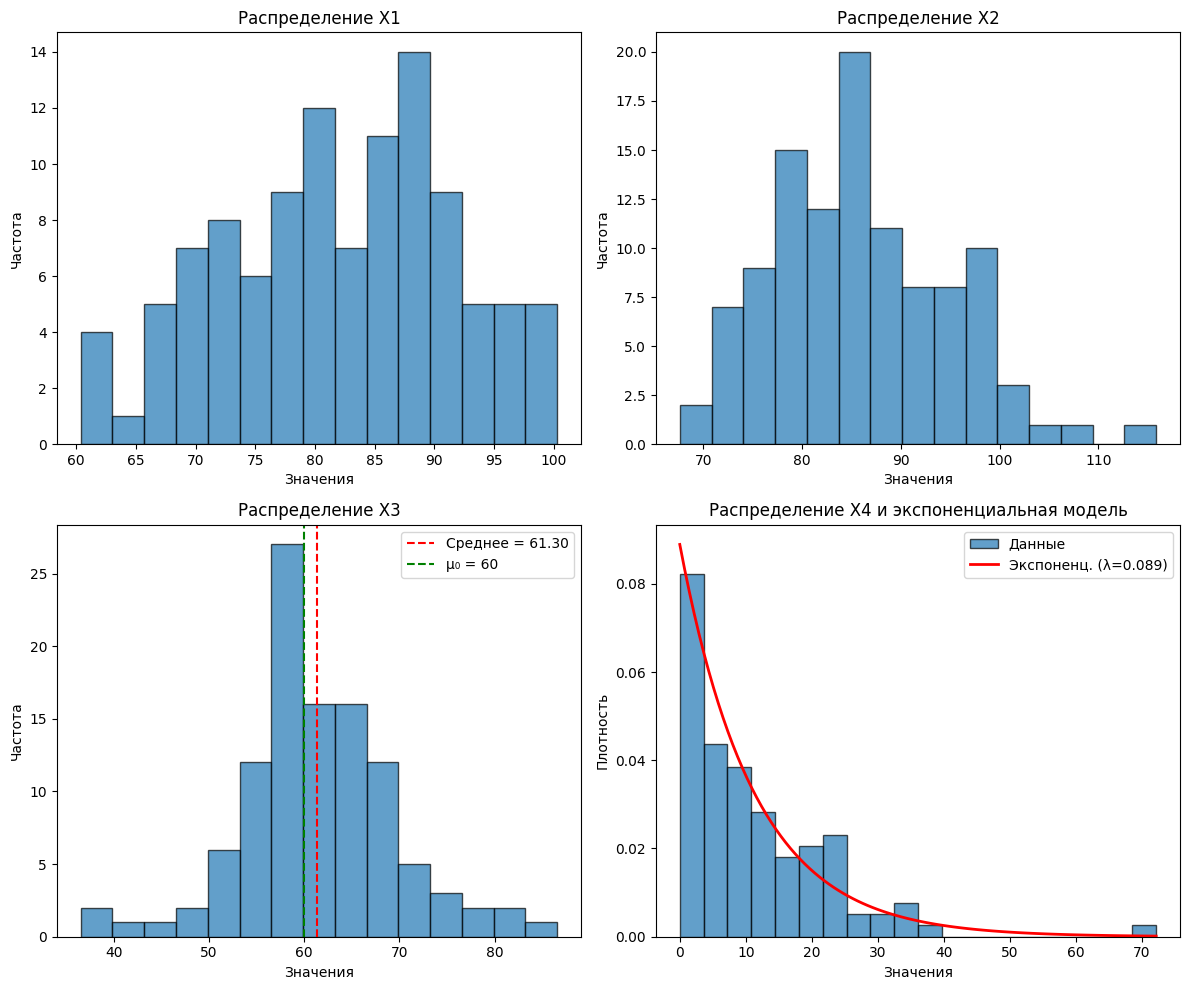

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Гистограмма X1
axes[0, 0].hist(df['X1'], bins=15, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение X1')
axes[0, 0].set_xlabel('Значения')
axes[0, 0].set_ylabel('Частота')

# Гистограмма X2
axes[0, 1].hist(df['X2'], bins=15, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Распределение X2')
axes[0, 1].set_xlabel('Значения')
axes[0, 1].set_ylabel('Частота')

# Гистограмма X3 с линией среднего
axes[1, 0].hist(df['X3'], bins=15, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['X3'].mean(), color='red', linestyle='--', label=f'Среднее = {df["X3"].mean():.2f}')
axes[1, 0].axvline(60, color='green', linestyle='--', label=f'μ₀ = 60')
axes[1, 0].set_title('Распределение X3')
axes[1, 0].set_xlabel('Значения')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()

# Гистограмма X4 с наложением экспоненциального распределения
axes[1, 1].hist(df['X4'], bins=20, density=True, edgecolor='black', alpha=0.7, label='Данные')
x = np.linspace(0, df['X4'].max(), 100)
axes[1, 1].plot(x, stats.expon.pdf(x, scale=1/lambda_est), 'r-', linewidth=2, label=f'Экспоненц. (λ={lambda_est:.3f})')
axes[1, 1].set_title('Распределение X4 и экспоненциальная модель')
axes[1, 1].set_xlabel('Значения')
axes[1, 1].set_ylabel('Плотность')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 6. Итоговый вывод

In [73]:
# ============================================================
# 4.6. Итоговый вывод
# ============================================================

print("=" * 65)
print("ОБЩИЙ ИТОГ РАСЧЁТНО-ГРАФИЧЕСКОЙ РАБОТЫ №2")
print("=" * 65)

# Определяем результаты
res_ttest = "отвергается" if p_value_x1_x2 < alpha else "не отвергается"
res_x3 = "отвергается" if p_value_x3 < alpha else "не отвергается"
res_mw = "отвергается" if p_value_mw < alpha else "не отвергается"
res_chi2 = "отвергается" if p_value_chi2 < alpha else "не отвергается"

# Краткий свод
print(f"""
В рамках работы проверены четыре статистические гипотезы на уровне значимости α = 0.05.

1. Параметрическое сравнение X1 и X2 (t-критерий Стьюдента):
   H₀: μ₁ = μ₂. p-value = {p_value_x1_x2:.4f} → H₀ {res_ttest}.
   Средние значения в двух выборках статистически {"различаются." if res_ttest == "отвергается" else "не различаются."}

2. Проверка гипотезы о среднем X3 (одновыборочный t-критерий):
   H₀: μ = 62.55. p-value = {p_value_x3:.4f} → H₀ {res_x3}.
   Среднее значение X3 {"значимо отличается от 62.55." if res_x3 == "отвергается" else "не отличается от 62.55 значимо."}

3. Непараметрическое сравнение X1 и X2 (критерий Манна–Уитни):
   H₀: распределения X1 и X2 одинаковы. p-value = {p_value_mw:.4f} → H₀ {res_mw}.
   Вывод {"совпадает" if (res_ttest == res_mw) else "расходится"} с результатом t-теста, что {"подтверждает устойчивость выводов." if (res_ttest == res_mw) else "может объясняться отклонением от нормальности."}

4. Критерий согласия для X4 (χ² Пирсона):
   H₀: X₄ ~ Exp(λ = 0.085). p-value = {p_value_chi2:.4f} → H₀ {res_chi2}.
   Эмпирическое распределение X4 {"не противоречит показательному закону с заданным параметром." if res_chi2 == "не отвергается" else "статистически значимо отличается от Exp(0.085)."}

Таким образом, на основании имеющихся данных и выбранного уровня значимости:
- {"обнаружены значимые различия средних в X1 и X2," if res_ttest == "отвергается" else "нет оснований говорить о различии средних в X1 и X2,"}
- {"среднее X3 отличается от нормативного значения 62.55," if res_x3 == "отвергается" else "среднее X3 соответствует нормативу 62.55,"}
- {"распределения X1 и X2 значимо различаются (непараметрический тест)," if res_mw == "отвергается" else "распределения X1 и X2 также не показывают значимых различий,"}
- {"распределение X4 согласуется с экспоненциальной моделью Exp(0.085)." if res_chi2 == "не отвергается" else "распределение X4 не соответствует Exp(0.085)."}
""")

ОБЩИЙ ИТОГ РАСЧЁТНО-ГРАФИЧЕСКОЙ РАБОТЫ №2

В рамках работы проверены четыре статистические гипотезы на уровне значимости α = 0.05.

1. Параметрическое сравнение X1 и X2 (t-критерий Стьюдента):
   H₀: μ₁ = μ₂. p-value = 0.0018 → H₀ отвергается.
   Средние значения в двух выборках статистически различаются.

2. Проверка гипотезы о среднем X3 (одновыборочный t-критерий):
   H₀: μ = 62.55. p-value = 0.1140 → H₀ не отвергается.
   Среднее значение X3 не отличается от 62.55 значимо.

3. Непараметрическое сравнение X1 и X2 (критерий Манна–Уитни):
   H₀: распределения X1 и X2 одинаковы. p-value = 0.0091 → H₀ отвергается.
   Вывод совпадает с результатом t-теста, что подтверждает устойчивость выводов.

4. Критерий согласия для X4 (χ² Пирсона):
   H₀: X₄ ~ Exp(λ = 0.085). p-value = 0.4864 → H₀ не отвергается.
   Эмпирическое распределение X4 не противоречит показательному закону с заданным параметром.

Таким образом, на основании имеющихся данных и выбранного уровня значимости:
- обнаружены знач